# Сравнение методов кластеризации KMEANS

In [1]:
import pandas as pd
import glob

In [2]:
configs = {
    'TF-IDF': {
        'path': '../data/results/metrics/tfidf/tfidf_kmeans_metrics.csv',
        'pca_dim': 50,
        'k': 14
    },
    'SBERT': {
        'path': '../data/results/metrics/sbert/sbert_kmeans_metrics.csv',
        'pca_dim': 50,
        'k': 14
    },
    'BGE-M3': {
        'path': '../data/results/metrics/bge/bge_kmeans_metrics.csv',
        'pca_dim': 50,
        'k': 15
    },
    'E5': {
        'path': '../data/results/metrics/e5/e5_kmeans_metrics.csv',
        'pca_dim': 50,
        'k': 16
    }
}

In [3]:
results = []

for model_name, cfg in configs.items():
    df_metrics = pd.read_csv(cfg['path'])
    
    # Фильтруем по выбранной размерности (если колонка 'pca_dim' существует)
    if 'pca_dim' in df_metrics.columns:
        filtered = df_metrics[(df_metrics['pca_dim'] == cfg['pca_dim']) & (df_metrics['k'] == cfg['k'])]
    else:
        # Для TF-IDF или если нет колонки с размерностью
        filtered = df_metrics[df_metrics['k'] == cfg['k']]
    
    if not filtered.empty:
        metrics_row = filtered.iloc[0].to_dict()
        results.append({
            'Model': model_name,
            'k': cfg['k'],
            'Silhouette': round(metrics_row.get('silhouette', 0), 4),
            'Calinski-Harabasz': round(metrics_row.get('calinski_harabasz', 0), 2),
            'Davies-Bouldin': round(metrics_row.get('davies_bouldin', 0), 4),
            'Dunn': round(metrics_row.get('dunn', 0), 6),
            'Gap': round(metrics_row.get('gap', 0), 6),
            'WSS': round(metrics_row.get('wss', 0), 2)
        })
    else:
        print(f"Не найдены метрики для {model_name} с k={cfg['k']} и pca={cfg['pca_dim']}")


In [5]:
comparison_df = pd.DataFrame(results)
comparison_df

,Model,k,Silhouette,Calinski-Harabasz,Davies-Bouldin,Dunn,Gap,WSS
0,TF-IDF,14,0.1085,336.08,2.6971,0.107212,1.882725,6144.21
1,SBERT,14,0.0375,403.12,3.4110,0.124658,2.976056,2057.56
2,BGE-M3,15,0.0728,308.50,2.9190,0.133342,2.950507,2105.32
3,E5,16,0.0778,351.43,2.6694,0.070197,4.463712,462.82


Теперь посмотрим как посты определяются в кластеры у разных моделей

In [7]:
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import chi2_contingency

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 100)
plt.style.use('seaborn-v0_8-whitegrid')

Загружаем

In [22]:
df_main = pd.read_csv("../data/split/02_text_for_vectorization.csv")
df_tfidf = pd.read_csv("../data/results/final_clusters/tfidf/tfidf_final_clusters.csv")
df_sbert = pd.read_csv("../data/results/final_clusters/sbert/sbert_final_clusters.csv")
df_bge = pd.read_csv("../data/results/final_clusters/bge/bge_final_clusters.csv")
df_e5 = pd.read_csv("../data/results/final_clusters/e5/e5_final_clusters.csv")

Оставляем только нужные колонки

In [23]:
df_tfidf_clean = df_tfidf[['post_id', 'channel_username', 'cluster_tfidf', 'cluster_tfidf_name']]
df_sbert_clean = df_sbert[['post_id', 'channel_username', 'cluster_sbert', 'cluster_sbert_name']]
df_bge_clean = df_bge[['post_id', 'channel_username', 'cluster_bge', 'cluster_bge_name']]
df_e5_clean = df_e5[['post_id', 'channel_username', 'cluster_e5', 'cluster_e5_name']]

Объединяем все с основным датафреймом

In [24]:
df_all = df_main.merge(df_tfidf_clean, on=['post_id', 'channel_username'], how='inner')
df_all = df_all.merge(df_sbert_clean, on=['post_id', 'channel_username'], how='inner')
df_all = df_all.merge(df_bge_clean, on=['post_id', 'channel_username'], how='inner')
df_all = df_all.merge(df_e5_clean, on=['post_id', 'channel_username'], how='inner')

In [25]:
df_all.head()

,channel_username,post_id,text,text_clean,text_tfidf,text_transformer,cluster_tfidf,cluster_tfidf_name,cluster_sbert,cluster_sbert_name,cluster_bge,cluster_bge_name,cluster_e5,cluster_e5_name
0,AI_point_of_view,1813,🤔 Искусственный интеллект: угроза или новые во...,искусственный интеллект: угроза или новые возм...,искусствен интеллект: угроз нов возможности? с...,искусственный интеллект: угроза или новые возм...,3,"Сколтех: AI, инженерия, наука и конференции",1,"Наука, образование и ИИ-разработки (Сколтех, С...",8,"Умные посты: ТРИЗ, RAG, лайфхаки",2,ИИ-исследования: конференции и наука
1,AI_point_of_view,1809,👩‍🎓 **Самообучение без разметки: лекция Алексе...,самообучение без разметки: лекция алексея зайц...,самообучен разметки: лекц алексе зайцев студен...,самообучение без разметки: лекция алексея зайц...,3,"Сколтех: AI, инженерия, наука и конференции",9,"Глобальные тренды ИИ: AGI, роботы, OpenAI и да...",8,"Умные посты: ТРИЗ, RAG, лайфхаки",2,ИИ-исследования: конференции и наука
2,AI_point_of_view,1808,📡▶️ **Искусственный интеллект: как научить маш...,искусственный интеллект: как научить машину чу...,искусствен интеллект: науч машин чувствова вре...,искусственный интеллект: как научить машину чу...,3,"Сколтех: AI, инженерия, наука и конференции",1,"Наука, образование и ИИ-разработки (Сколтех, С...",8,"Умные посты: ТРИЗ, RAG, лайфхаки",2,ИИ-исследования: конференции и наука
3,AI_point_of_view,1805,*️⃣**Физика + ИИ** **от Сколтеха** **Владимир ...,"физика ии от сколтеха владимир вановский, руко...","физик сколтех владимир вановский, руководител ...","физика ии от сколтеха владимир вановский, руко...",3,"Сколтех: AI, инженерия, наука и конференции",11,Прикладные научные исследования и интервью с у...,8,"Умные посты: ТРИЗ, RAG, лайфхаки",2,ИИ-исследования: конференции и наука
4,AI_point_of_view,1804,⚡️**ЗАВТРА:** **Sber Conf: Open Source & AI Ag...,завтра: sber conf: open source ai agents! сбер...,завтра: sber conf: open source agents! сбер со...,завтра: sber conf: open source ai agents! сбер...,2,"IT-образование и стажировки (Т-Банк, Яндекс, к...",9,"Глобальные тренды ИИ: AGI, роботы, OpenAI и да...",8,"Умные посты: ТРИЗ, RAG, лайфхаки",5,Утренние дайджесты новостей ИИ


In [40]:
cluster_info = []

# TF-IDF
for cluster_id in sorted(df_all['cluster_tfidf'].unique()):
    name = df_all[df_all['cluster_tfidf'] == cluster_id]['cluster_tfidf_name'].iloc[0]
    cluster_info.append({
        'Модель': 'TF-IDF',
        'ID кластера': cluster_id,
        'Название кластера': name,
        'Количество постов': (df_all['cluster_tfidf'] == cluster_id).sum()
    })

# SBERT
for cluster_id in sorted(df_all['cluster_sbert'].unique()):
    name = df_all[df_all['cluster_sbert'] == cluster_id]['cluster_sbert_name'].iloc[0]
    cluster_info.append({
        'Модель': 'SBERT',
        'ID кластера': cluster_id,
        'Название кластера': name,
        'Количество постов': (df_all['cluster_sbert'] == cluster_id).sum()
    })

# BGE-M3
for cluster_id in sorted(df_all['cluster_bge'].unique()):
    name = df_all[df_all['cluster_bge'] == cluster_id]['cluster_bge_name'].iloc[0]
    cluster_info.append({
        'Модель': 'BGE-M3',
        'ID кластера': cluster_id,
        'Название кластера': name,
        'Количество постов': (df_all['cluster_bge'] == cluster_id).sum()
    })

# E5
for cluster_id in sorted(df_all['cluster_e5'].unique()):
    name = df_all[df_all['cluster_e5'] == cluster_id]['cluster_e5_name'].iloc[0]
    cluster_info.append({
        'Модель': 'E5',
        'ID кластера': cluster_id,
        'Название кластера': name,
        'Количество постов': (df_all['cluster_e5'] == cluster_id).sum()
    })

df_cluster_info = pd.DataFrame(cluster_info)
print("\nВсе кластеры по моделям:")
print(df_cluster_info.to_string(index=False))


Все кластеры по моделям:
Модель  ID кластера                                                       Название кластера  Количество постов
TF-IDF            0                                          Apple: инсайды, слухи и релизы                823
TF-IDF            1                           SOTA LLM: бенчмарки, OpenAI, DeepSeek, Gemini                811
TF-IDF            2                     IT-образование и стажировки (Т-Банк, Яндекс, курсы)                802
TF-IDF            3                             Сколтех: AI, инженерия, наука и конференции                663
TF-IDF            4                        Telegram: блокчейн, подарки, TON и криптоновости                547
TF-IDF            5                             Игровая индустрия: анонсы, трейлеры, релизы                433
TF-IDF            6                               Утренние дайджесты: глобальные AI-новости                748
TF-IDF            7                     Мусорный кластер: личное, финансы, космос, лай

## Работа с результатами кластеризации: вовлечённость и реакции по темам (E5)

In [18]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics.pairwise import cosine_distances
from collections import Counter

In [56]:
e5 = pd.read_csv('../data/results/final_clusters/e5/e5_final_clusters.csv')
reactions = pd.read_csv('../data/split/04_reactions.csv')
# Вовлеченность
engagement = pd.read_csv('../data/split/03_engagement.csv')

In [57]:
for df in [e5, engagement, reactions]:
    df['key'] = df['channel_username'] + '_' + df['post_id'].astype(str)

In [70]:

mapping_e5_short = {
    0: "Регулирование",
    1: "Кино и YouTube",
    2: "Наука и ИИ",
    3: "Университет",
    4: "Apple",
    5: "Новости",
    6: "Интерактив",
    7: "Тренды ИИ",
    8: "Игры",
    9: "Наука и ИИ",      # второй кластер науки
    10: "ИИ-инструменты",
    11: "Telegram",
    12: "Кибербезопасность",
    13: "Финансы",
    14: "Авто",
    15: "IT-образование"
}

e5['topic'] = e5['cluster_e5'].map(mapping_e5_short)

In [71]:

df_eng = e5.merge(engagement[['key', 'views_norm', 'reaction_norm', 'forward_norm', 
                          'engagement_rate', 'views']], on='key', how='inner')


In [72]:

engagement_by_topic = df_eng.groupby('topic').agg({
    'engagement_rate': 'mean',
    'views_norm': 'mean',
    'reaction_norm': 'mean',
    'forward_norm': 'mean',
    'key': 'count'
}).rename(columns={'key': 'n_posts'}).sort_values('engagement_rate', ascending=False)

In [73]:
print("\n=== Вовлечённость по темам (E5 K-Means) ===")
print(engagement_by_topic.round(4))



=== Вовлечённость по темам (E5 K-Means) ===
                   engagement_rate  views_norm  reaction_norm  forward_norm  \
topic                                                                         
Наука и ИИ                  0.0296      0.2649         0.0201        0.0094   
Новости                     0.0224      0.2067         0.0144        0.0079   
Университет                 0.0212      0.3277         0.0161        0.0050   
IT-образование              0.0210      0.3273         0.0116        0.0094   
Тренды ИИ                   0.0197      0.2754         0.0119        0.0078   
Интерактив                  0.0181      0.2435         0.0123        0.0058   
ИИ-инструменты              0.0167      0.1225         0.0055        0.0111   
Регулирование               0.0165      0.1135         0.0108        0.0057   
Кино и YouTube              0.0162      0.1214         0.0075        0.0086   
Кибербезопасность           0.0157      0.1309         0.0097        0.0060   
Авто   

In [75]:

df = e5.merge(engagement[['key', 'views']], on='key', how='inner')

In [76]:
# Словари реакций
positive_set = {'⚡', '✍', '🆒', '🍾', '🎉', '🏆', '👌', '👍', '👏', '💯', '🔥', '😁', '😍', '😎', '😘', '🙏', '🤝', '🤩', '🥰', '🫡', '❤️', '⭐', '💅', '🤗', '🤣', '👻', '😇', '😈', '🥹', '🤪'}
neutral_set = {'👀', '🤔', '😐', '🤓', '🔦', '🗣', '👨‍💻', '🕊', '🤖', '🧑‍🎓', '👾', '🗿', '☃', '🎄', '🎅', '🎃', '🦄', '🐳', '🌚'}
negative_set = {'👎', '😢', '😴', '🥱', '💔', '💩', '😭', '🚫', '😡', '🤡'}
surprise_set = {'🤯', '😱', '🙊', '😨'}

reaction_cols = [c for c in reactions.columns if c.startswith('reaction_')]

def count_reaction_types(row, reaction_set):
    return sum(row[col] for col in reaction_cols if col.replace('reaction_', '') in reaction_set)

# Считаем количество реакций каждого типа для каждого поста
reactions['positive_count'] = reactions.apply(lambda x: count_reaction_types(x, positive_set), axis=1)
reactions['neutral_count'] = reactions.apply(lambda x: count_reaction_types(x, neutral_set), axis=1)
reactions['negative_count'] = reactions.apply(lambda x: count_reaction_types(x, negative_set), axis=1)
reactions['surprise_count'] = reactions.apply(lambda x: count_reaction_types(x, surprise_set), axis=1)

In [77]:
df_reactions = df.merge(
    reactions[['key', 'positive_count', 'neutral_count', 'negative_count', 'surprise_count']],
    on='key', how='inner'
)

# ============================================
# Нормируем каждый тип реакций на просмотры
# ============================================

reaction_types = ['positive_count', 'neutral_count', 'negative_count', 'surprise_count']
for col in reaction_types:
    df_reactions[f'{col}_norm'] = df_reactions[col] / (df_reactions['views'] + 1)

# ============================================
# Агрегация по темам (среднее нормированных значений)
# ============================================

reactions_norm_by_topic = df_reactions.groupby('topic').agg({
    f'{col}_norm': 'mean' for col in reaction_types
}).round(5)

print("=== Реакции по темам (нормированные на просмотры) ===")
print(reactions_norm_by_topic)

=== Реакции по темам (нормированные на просмотры) ===
                   positive_count_norm  neutral_count_norm  \
topic                                                        
Apple                          0.00376             0.00057   
IT-образование                 0.01031             0.00126   
Telegram                       0.00538             0.00079   
Авто                           0.00639             0.00057   
ИИ-инструменты                 0.00429             0.00084   
Игры                           0.00501             0.00052   
Интерактив                     0.01110             0.00094   
Кибербезопасность              0.00595             0.00142   
Кино и YouTube                 0.00626             0.00058   
Наука и ИИ                     0.01880             0.00131   
Новости                        0.01148             0.00237   
Регулирование                  0.00573             0.00072   
Тренды ИИ                      0.00931             0.00169   
Университет     

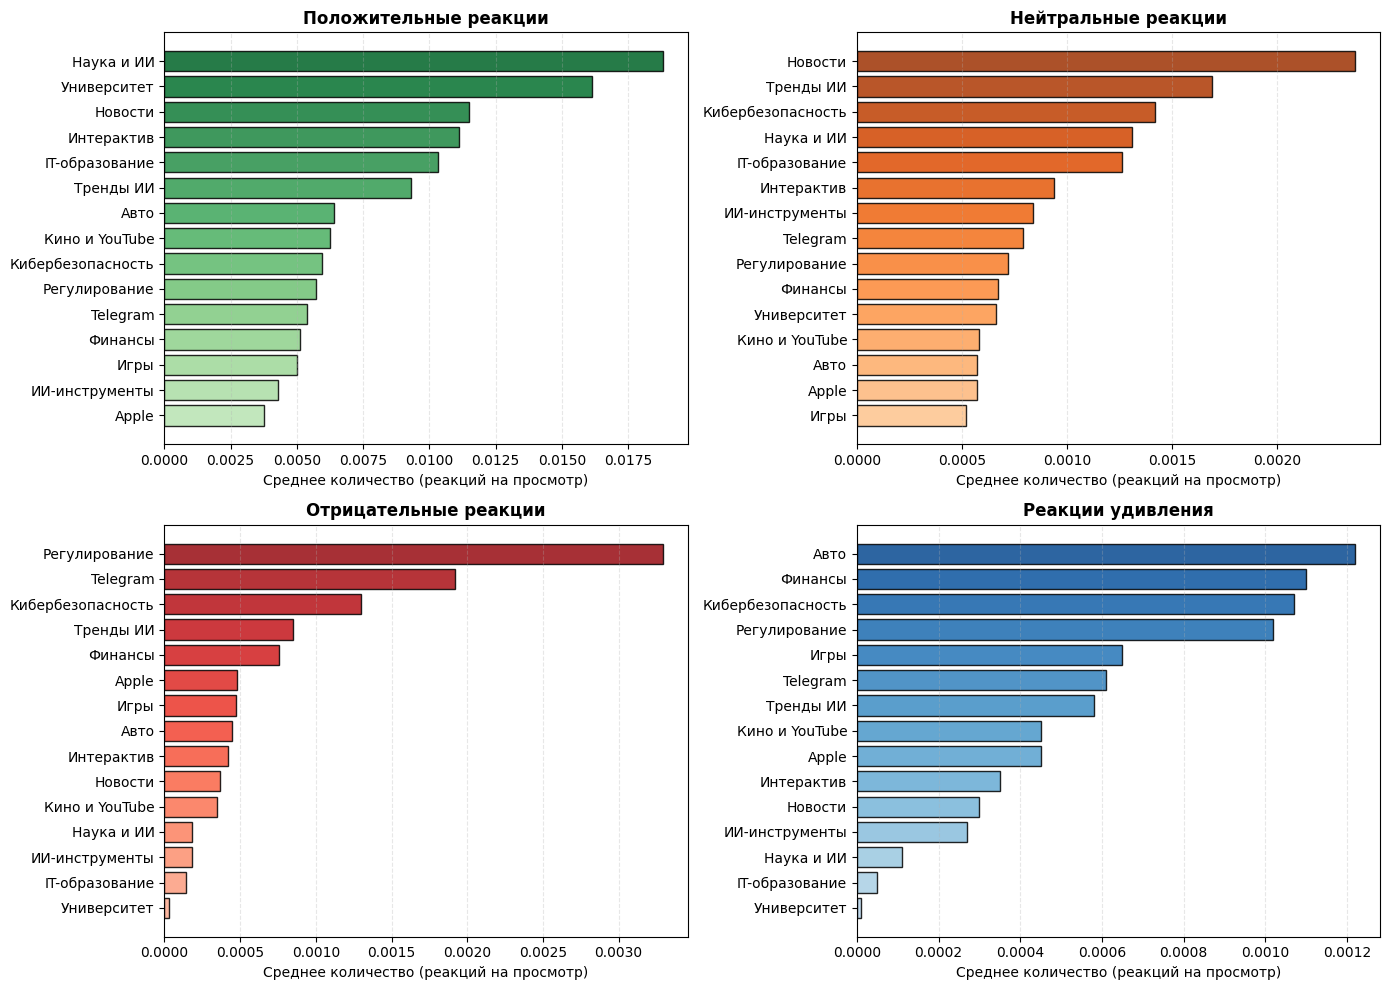

In [83]:

fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# Цвета
positive_cmap = plt.cm.Greens
neutral_cmap = plt.cm.Oranges
negative_cmap = plt.cm.Reds
surprise_cmap = plt.cm.Blues

reaction_metrics = ['positive_count_norm', 'neutral_count_norm', 'negative_count_norm', 'surprise_count_norm']
reaction_titles = ['Положительные реакции', 'Нейтральные реакции', 'Отрицательные реакции', 'Реакции удивления']
cmaps = [positive_cmap, neutral_cmap, negative_cmap, surprise_cmap]

for ax, metric, title, cmap in zip(axes.flatten(), reaction_metrics, reaction_titles, cmaps):
    data = reactions_norm_by_topic[[metric]].sort_values(metric, ascending=True)
    # Создаём цвета от светлого к тёмному
    colors = cmap(np.linspace(0.3, 0.9, len(data)))
    ax.barh(data.index, data[metric], color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Среднее количество (реакций на просмотр)', fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/plots/reactions_by_topic_e5.png', dpi=200, bbox_inches='tight')
plt.show()

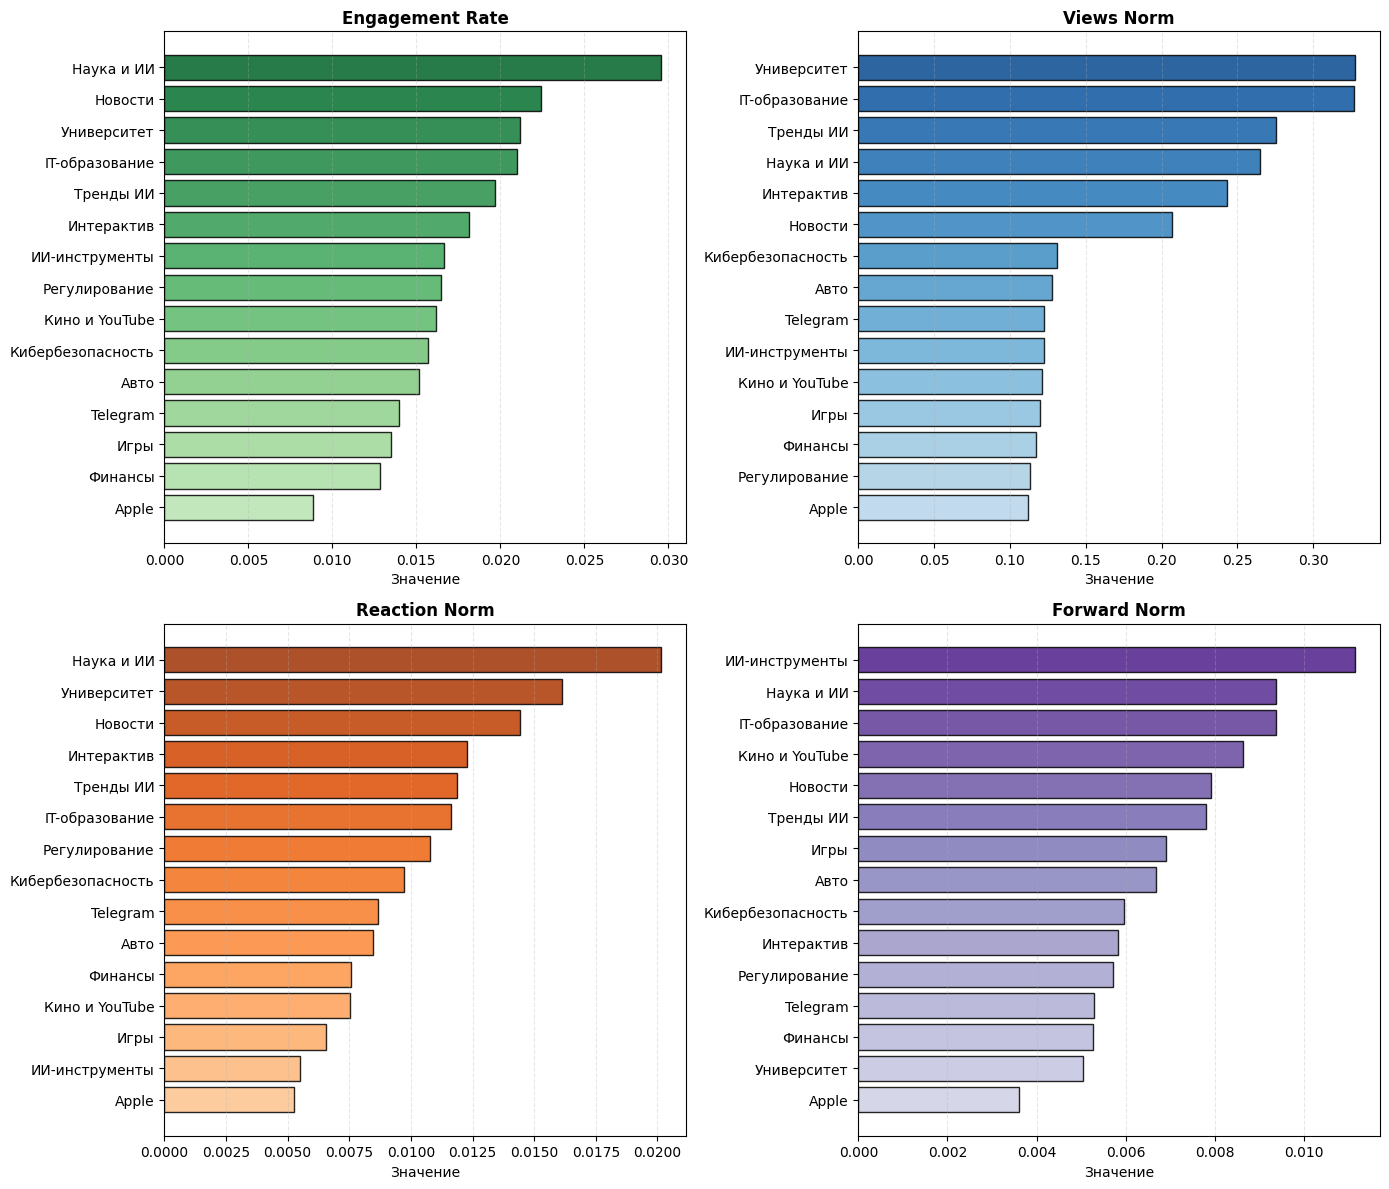

In [87]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

# ============================================
# 4 отдельных графика с разными палитрами
# ============================================

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

metrics_plot = ['engagement_rate', 'views_norm', 'reaction_norm', 'forward_norm']
titles_plot = ['Engagement Rate', 'Views Norm', 'Reaction Norm', 'Forward Norm']

# Разные палитры для каждого графика
palettes = [
    plt.cm.Greens,      # engagement_rate
    plt.cm.Blues,       # views_norm
    plt.cm.Oranges,     # reaction_norm
    plt.cm.Purples      # forward_norm
]

for ax, metric, title, cmap in zip(axes.flatten(), metrics_plot, titles_plot, palettes):
    # Сортируем по текущей метрике
    df_sorted = engagement_by_topic[[metric]].sort_values(metric, ascending=True)
    colors = cmap(np.linspace(0.3, 0.9, len(df_sorted)))
    ax.barh(df_sorted.index, df_sorted[metric], color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Значение', fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/plots/four_metrics_separate.png', dpi=200, bbox_inches='tight')
plt.show()

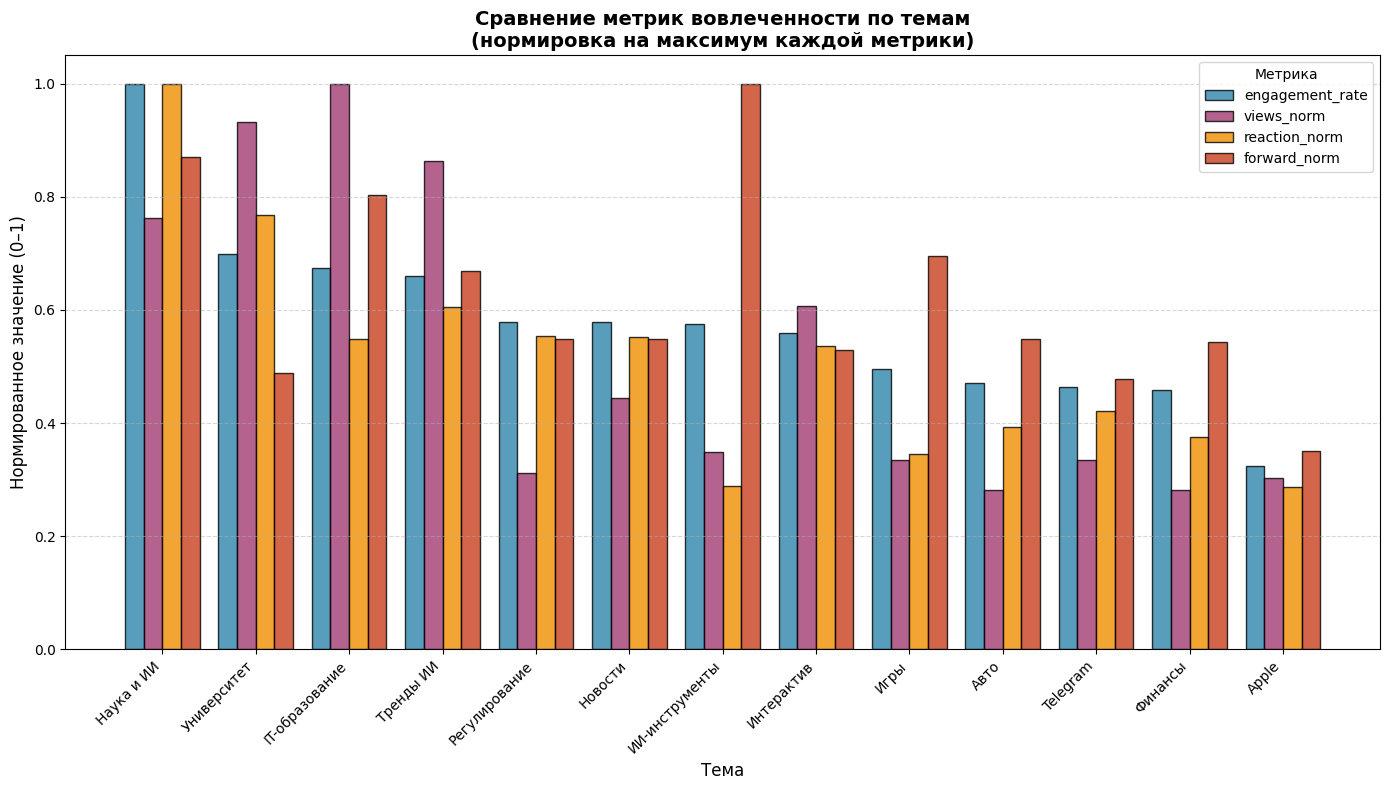

In [21]:
# ============================================
# Визуализация: grouped bar chart (engagement, views, reactions, forwards)
# ============================================

fig, ax = plt.subplots(figsize=(14, 8))

metrics_to_plot = ['engagement_rate', 'views_norm', 'reaction_norm', 'forward_norm']
# Нормируем для визуализации (чтобы все были в сопоставимом масштабе)
plot_data = engagement_by_topic[metrics_to_plot].copy()
for col in plot_data.columns:
    plot_data[col] = plot_data[col] / plot_data[col].max()  # нормировка на максимум

x = np.arange(len(plot_data.index))
width = 0.2
multiplier = 0

colors = {'engagement_rate': '#2E86AB', 'views_norm': '#A23B72', 'reaction_norm': '#F18F01', 'forward_norm': '#C73E1D'}

for metric in metrics_to_plot:
    offset = width * multiplier
    ax.bar(x + offset, plot_data[metric], width, label=metric, color=colors[metric], alpha=0.8, edgecolor='black')
    multiplier += 1

ax.set_xlabel('Тема', fontsize=12)
ax.set_ylabel('Нормированное значение (0–1)', fontsize=12)
ax.set_title('Сравнение метрик вовлеченности по темам\n(нормировка на максимум каждой метрики)', fontsize=14, fontweight='bold')
ax.set_xticks(x + width * 1.5)
ax.set_xticklabels(plot_data.index, rotation=45, ha='right', fontsize=10)
ax.legend(loc='upper right', title='Метрика')
ax.grid(axis='y', linestyle='--', alpha=0.5)
plt.tight_layout()
plt.savefig('../data/plots/engagement_metrics_grouped.png', dpi=200, bbox_inches='tight')
plt.show()

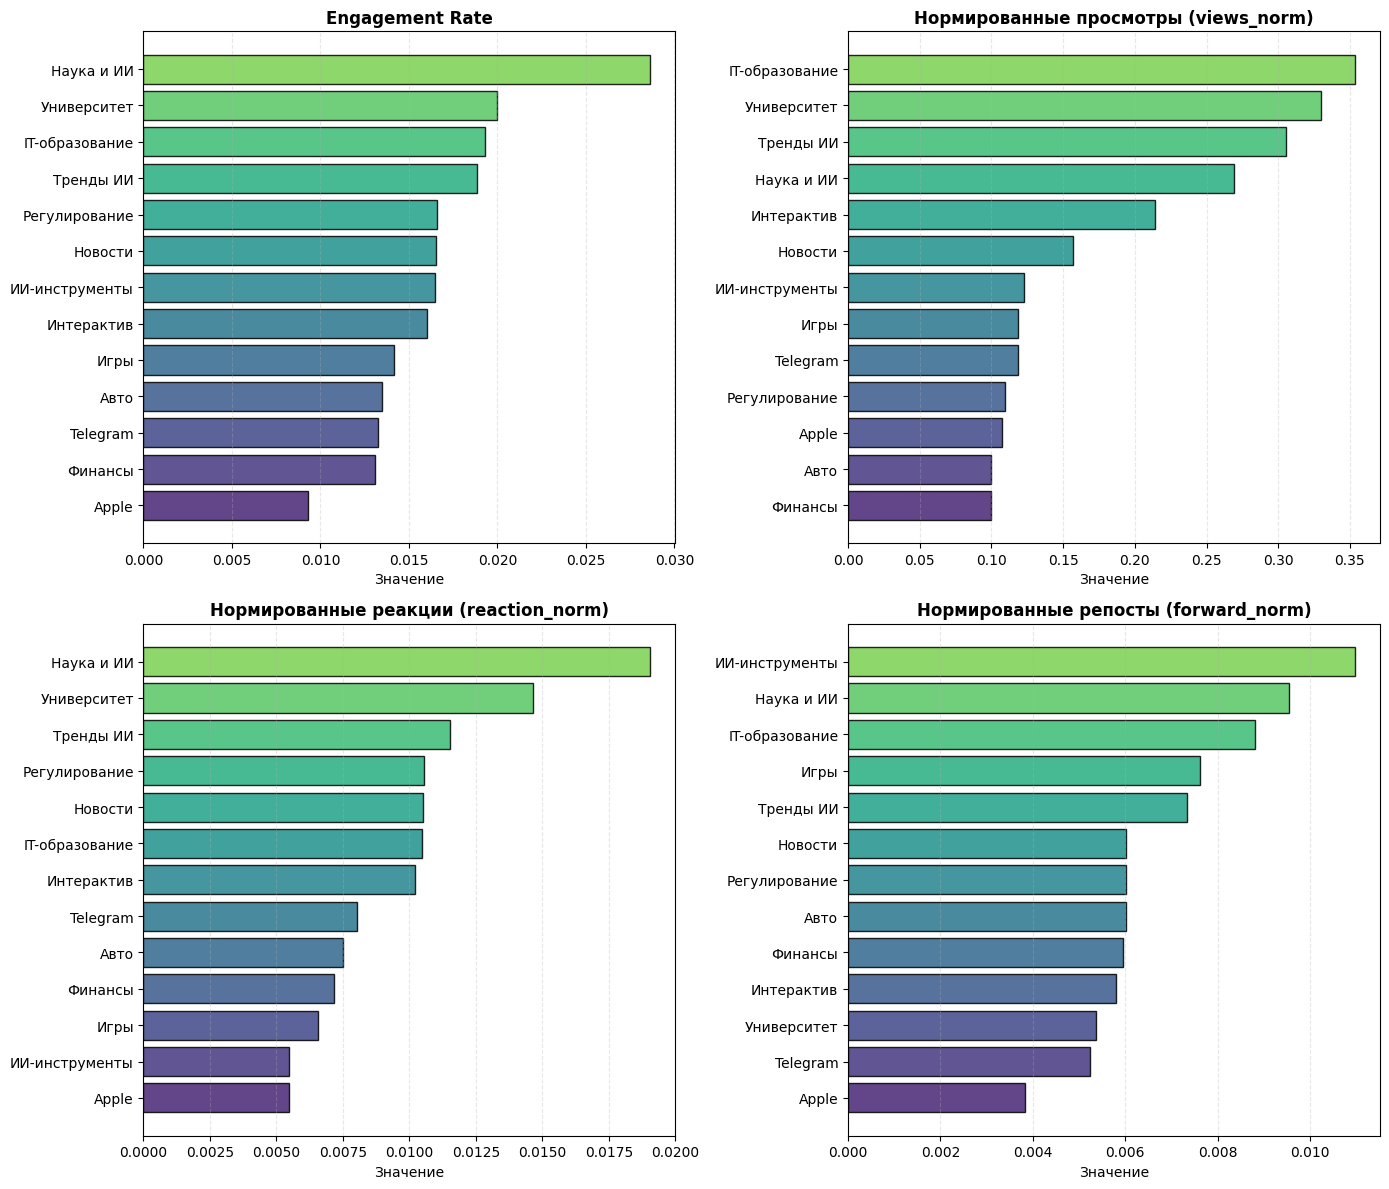

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

fig, axes = plt.subplots(2, 2, figsize=(14, 12))

metrics = ['engagement_rate', 'views_norm', 'reaction_norm', 'forward_norm']
titles = ['Engagement Rate', 'Просмотры', 
          'Реакции', 'Репосты']
cmap_global = plt.cm.viridis

for ax, metric, title in zip(axes.flatten(), metrics, titles):
    data = engagement_by_topic[[metric]].sort_values(metric, ascending=True)
    colors = cmap_global(np.linspace(0.1, 0.8, len(data)))
    ax.barh(data.index, data[metric], color=colors, edgecolor='black', alpha=0.85)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('Значение', fontsize=10)
    ax.grid(axis='x', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.savefig('../data/plots/four_metrics_engagement_horizontal.png', dpi=200, bbox_inches='tight')
plt.show()

# Приведение названий кластеров к единому формату

На основе ручного анализа всех моделей выделены следующие обобщенные темы:

| № | Обобщенная категория |
|---|----------------------|
| 1 | Экосистема Telegram |
| 2 | Apple и iOS |
| 3 | Игровая индустрия |
| 4 | IT-образование и карьера |
| 5 | Научные исследования и ИИ (Сколтех, российская наука) |
| 6 | Глобальные тренды ИИ (OpenAI, Google, LLM) |
| 7 | ИИ-инструменты и разработка (vibe coding) |
| 8 | Новости и дайджесты |
| 9 | Госрегулирование и блокировки |
| 10 | Кино, сериалы, YouTube |
| 11 | Опросы и интерактив |
| 12 | Юмор и развлекательный контент |
| 13 | Финансы и криптовалюты |
| 14 | Автомобили и транспорт |
| 15 | СПбГУ и университетская жизнь |
| 16 | Прочее / смешанный контент |
| 17 | Психология, нейронауки |
| 18 | Кибербезопасность, DDoS, утечки данных |


In [50]:
# TF-IDF
mapping_tfidf = {
    0: "Apple и iOS",
    1: "Глобальные тренды ИИ",
    2: "IT-образование и карьера",
    3: "Научные исследования и ИИ",
    4: "Экосистема Telegram",
    5: "Игровая индустрия",
    6: "Новости и дайджесты",
    7: "Прочее / смешанный контент",
    8: "Госрегулирование и блокировки",
    9: "Научные исследования и ИИ",
    10: "ИИ-инструменты и разработка",
    11: "СПбГУ и университетская жизнь",
    12: "Новости и дайджесты",
    13: "Опросы и интерактив",
}

# SBERT
mapping_sbert = {
    0: "Госрегулирование и блокировки",
    1: "Научные исследования и ИИ",
    2: "СПбГУ и университетская жизнь",
    3: "IT-образование и карьера",
    4: "Игровая индустрия",
    5: "Новости и дайджесты",
    6: "Экосистема Telegram",
    7: "Apple и iOS",
    8: "Юмор и развлекательный контент",
    9: "Глобальные тренды ИИ",
    10: "Apple и iOS",
    11: "Научные исследования и ИИ",
    12: "ИИ-инструменты и разработка",
    13: "Опросы и интерактив",
}

# BGE-M3
mapping_bgem3 = {
    0: "Госрегулирование и блокировки",
    1: "Игровая индустрия",
    2: "СПбГУ и университетская жизнь",
    3: "Научные исследования и ИИ",
    4: "Новости и дайджесты",
    5: "Экосистема Telegram",
    6: "IT-образование и карьера",
    7: "Психология, нейронауки",
    8: "Прочее / смешанный контент",
    9: "Apple и iOS",
    10: "Новости и дайджесты",
    11: "Глобальные тренды ИИ",
    12: "Кибербезопасность, DDoS, утечки данных",
    13: "ИИ-инструменты и разработка",
    14: "Юмор и развлекательный контент",
}

# E5
mapping_e5 = {
    0: "Госрегулирование и блокировки",
    1: "Кино, сериалы, YouTube",
    2: "Научные исследования и ИИ",
    3: "СПбГУ и университетская жизнь",
    4: "Apple и iOS",
    5: "Новости и дайджесты",
    6: "Прочее / смешанный контент",
    7: "Глобальные тренды ИИ",
    8: "Игровая индустрия",
    9: "Научные исследования и ИИ",
    10: "ИИ-инструменты и разработка",
    11: "Экосистема Telegram",
    12: "Кибербезопасность, DDoS, утечки данных",
    13: "Финансы и криптовалюты",
    14: "Автомобили и транспорт",
    15: "IT-образование и карьера",
}

In [51]:
# Добавляем обобщенные категории в датафрейм
df_all['topic_tfidf'] = df_all['cluster_tfidf'].map(mapping_tfidf)
df_all['topic_sbert'] = df_all['cluster_sbert'].map(mapping_sbert)
df_all['topic_bge'] = df_all['cluster_bge'].map(mapping_bgem3)
df_all['topic_e5'] = df_all['cluster_e5'].map(mapping_e5)

In [55]:
crosstab_tfidf_bge = pd.crosstab(df_all['topic_tfidf'], df_all['topic_bge'], normalize='index')

significant = crosstab_tfidf_bge.dropna(how='all', axis=0).dropna(how='all', axis=1)
significant.round(3)

topic_bge,Apple и iOS,IT-образование и карьера,Глобальные тренды ИИ,Госрегулирование и блокировки,ИИ-инструменты и разработка,"Кино, сериалы, YouTube",Научные исследования и ИИ,Новости и дайджесты,Прочее / смешанный контент,СПбГУ и университетская жизнь,Экосистема Telegram,Юмор и развлекательный контент
topic_tfidf,,,,,,,,,,,,
Apple и iOS,0.746,0.000,0.010,0.028,0.058,0.070,0.000,0.062,0.011,0.000,0.002,0.012
IT-образование и карьера,0.000,0.727,0.002,0.011,0.005,0.006,0.037,0.014,0.112,0.034,0.000,0.051
Глобальные тренды ИИ,0.006,0.001,0.578,0.001,0.058,0.028,0.001,0.059,0.243,0.000,0.000,0.023
Госрегулирование и блокировки,0.016,0.030,0.004,0.589,0.048,0.030,0.001,0.159,0.050,0.004,0.029,0.040
ИИ-инструменты и разработка,0.005,0.009,0.022,0.007,0.789,0.028,0.000,0.024,0.079,0.000,0.003,0.035
Игровая индустрия,0.005,0.009,0.002,0.016,0.072,0.753,0.002,0.048,0.021,0.002,0.005,0.065
Научные исследования и ИИ,0.000,0.029,0.001,0.003,0.001,0.001,0.478,0.040,0.395,0.029,0.000,0.022
Новости и дайджесты,0.002,0.002,0.018,0.015,0.033,0.007,0.002,0.779,0.140,0.000,0.000,0.003
Опросы и интерактив,0.021,0.043,0.050,0.036,0.007,0.029,0.014,0.071,0.236,0.000,0.014,0.479


In [56]:
crosstab_sbert_bge = pd.crosstab(df_all['topic_sbert'], df_all['topic_bge'], normalize='index')
significant_sbert = crosstab_sbert_bge.dropna(how='all', axis=0).dropna(how='all', axis=1)
significant_sbert.round(3)

topic_bge,Apple и iOS,IT-образование и карьера,Глобальные тренды ИИ,Госрегулирование и блокировки,ИИ-инструменты и разработка,"Кино, сериалы, YouTube",Научные исследования и ИИ,Новости и дайджесты,Прочее / смешанный контент,СПбГУ и университетская жизнь,Экосистема Telegram,Юмор и развлекательный контент
topic_sbert,,,,,,,,,,,,
Apple и iOS,0.675,0.003,0.008,0.049,0.086,0.025,0.002,0.142,0.002,0.000,0.008,0.002
IT-образование и карьера,0.023,0.129,0.092,0.069,0.060,0.112,0.053,0.120,0.113,0.087,0.010,0.130
Глобальные тренды ИИ,0.038,0.040,0.193,0.025,0.156,0.148,0.016,0.194,0.156,0.009,0.007,0.018
Госрегулирование и блокировки,0.088,0.053,0.022,0.276,0.076,0.057,0.022,0.125,0.080,0.022,0.061,0.119
ИИ-инструменты и разработка,0.018,0.120,0.075,0.087,0.191,0.040,0.020,0.103,0.163,0.066,0.014,0.103
Игровая индустрия,0.063,0.000,0.092,0.073,0.110,0.257,0.000,0.257,0.055,0.003,0.050,0.042
Научные исследования и ИИ,0.004,0.093,0.017,0.068,0.023,0.013,0.187,0.160,0.232,0.160,0.004,0.039
Новости и дайджесты,0.046,0.003,0.020,0.079,0.007,0.112,0.000,0.677,0.007,0.017,0.023,0.010
Опросы и интерактив,0.056,0.031,0.039,0.247,0.161,0.118,0.011,0.136,0.045,0.022,0.012,0.123


In [57]:
crosstab_e5_bge = pd.crosstab(df_all['topic_e5'], df_all['topic_bge'], normalize='index')
significant_e5 = crosstab_e5_bge.dropna(how='all', axis=0).dropna(how='all', axis=1)
significant_e5.round(3)

topic_bge,Apple и iOS,IT-образование и карьера,Глобальные тренды ИИ,Госрегулирование и блокировки,ИИ-инструменты и разработка,"Кино, сериалы, YouTube",Научные исследования и ИИ,Новости и дайджесты,Прочее / смешанный контент,СПбГУ и университетская жизнь,Экосистема Telegram,Юмор и развлекательный контент
topic_e5,,,,,,,,,,,,
Apple и iOS,0.704,0.000,0.013,0.022,0.044,0.053,0.000,0.152,0.004,0.000,0.004,0.002
IT-образование и карьера,0.000,0.702,0.001,0.008,0.007,0.001,0.096,0.008,0.084,0.081,0.001,0.010
Автомобили и транспорт,0.002,0.000,0.000,0.108,0.014,0.358,0.004,0.141,0.014,0.000,0.000,0.358
Глобальные тренды ИИ,0.000,0.006,0.514,0.002,0.047,0.012,0.000,0.071,0.345,0.000,0.000,0.003
Госрегулирование и блокировки,0.005,0.002,0.005,0.741,0.002,0.000,0.003,0.136,0.012,0.002,0.092,0.003
ИИ-инструменты и разработка,0.005,0.010,0.023,0.004,0.863,0.009,0.000,0.032,0.044,0.000,0.000,0.010
Игровая индустрия,0.016,0.008,0.005,0.013,0.089,0.745,0.003,0.066,0.029,0.000,0.008,0.018
"Кибербезопасность, DDoS, утечки данных",0.038,0.006,0.011,0.377,0.038,0.008,0.000,0.367,0.046,0.006,0.084,0.019
"Кино, сериалы, YouTube",0.004,0.008,0.000,0.008,0.030,0.559,0.017,0.089,0.013,0.013,0.004,0.254


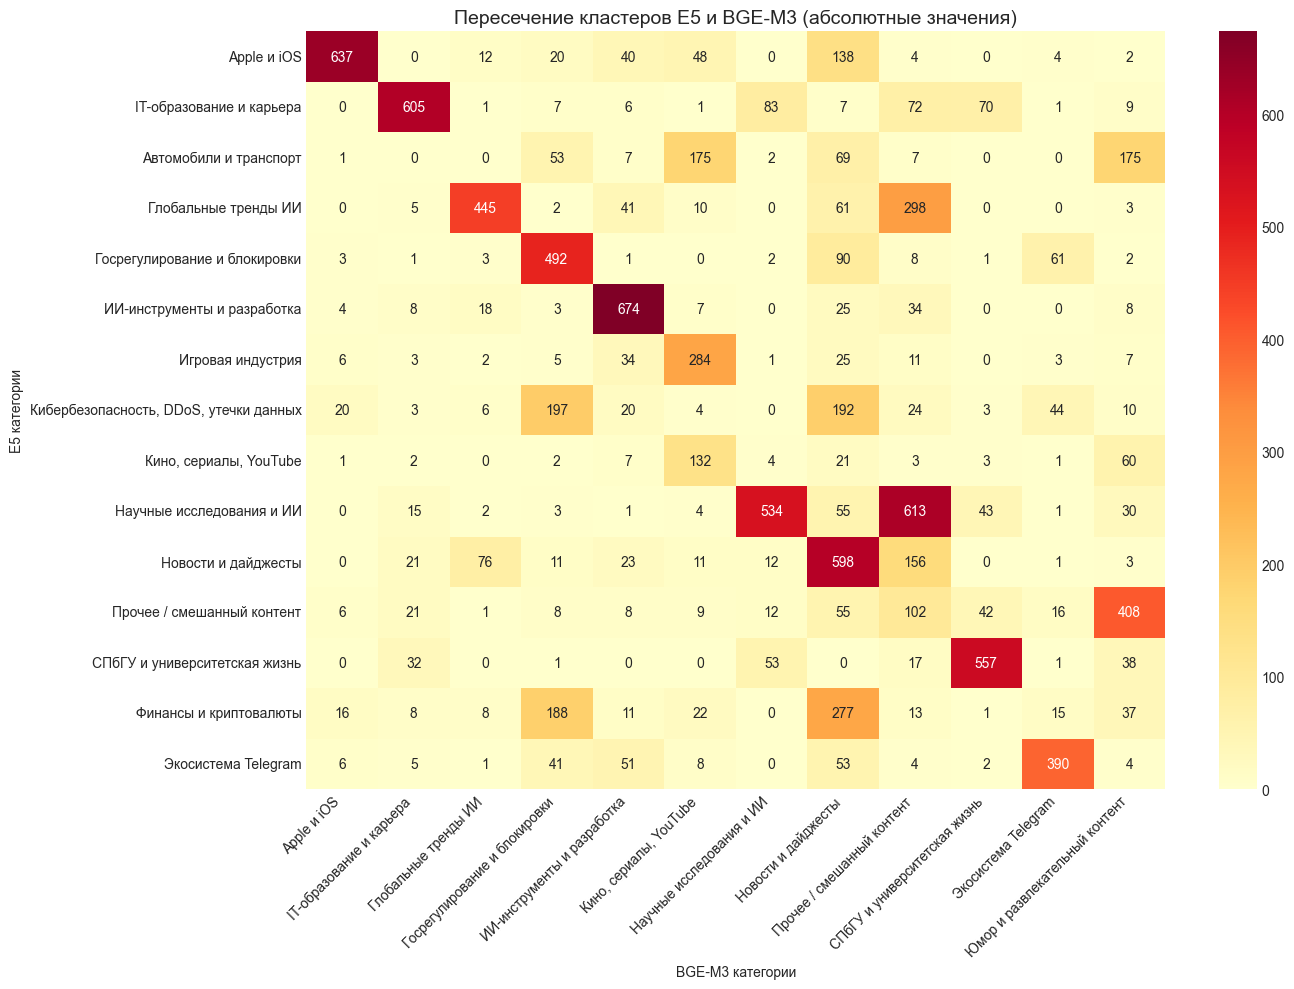

In [58]:
plt.figure(figsize=(14, 10))
# Берем абсолютные значения (не нормированные) для тепловой карты
crosstab_abs = pd.crosstab(df_all['topic_e5'], df_all['topic_bge'])
sns.heatmap(crosstab_abs, annot=True, fmt='d', cmap='YlOrRd', 
            xticklabels=True, yticklabels=True)
plt.title('Пересечение кластеров E5 и BGE-M3 (абсолютные значения)', fontsize=14)
plt.xlabel('BGE-M3 категории')
plt.ylabel('E5 категории')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.savefig('../data/plots/cross_tab_e5_bge.png', dpi=300, bbox_inches='tight')
plt.show()